# KDD Data Analysis and Attack Classification using Machine Learning & Neural Networks
This notebook covers data preprocessing, feature engineering, and training multiple ML models to classify attacks using the KDD dataset.

In [1]:
!pip install tensorflow

In [34]:

import pandas as pd  # Importing pandas for data handling
import numpy as np  # Importing numpy for numerical operations
import seaborn as sns  # Importing seaborn for visualization
import matplotlib.pyplot as plt  # Importing matplotlib for plotting graphs
from sklearn.model_selection import train_test_split  # Splitting dataset into train and test
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Encoding categorical variables and scaling data
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Importing classification models
from sklearn.svm import SVC  # Importing Support Vector Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score, f1_score # Evaluation metrics
import tensorflow as tf  # TensorFlow for deep learning
from tensorflow import keras  # Keras API for building models
from tensorflow.keras.models import Sequential  # Sequential model type
from tensorflow.keras.layers import Dense, Dropout  # Neural network layers


## Load the KDD dataset from URL

In [5]:

from sklearn.datasets import fetch_kddcup99
import pandas as pd

data = fetch_kddcup99(percent10=True, as_frame=True)

df = data.frame
df.columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
              "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
              "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
              "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
              "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
              "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

print(df.head())

  duration protocol_type  service   flag src_bytes dst_bytes land  \
0        0        b'tcp'  b'http'  b'SF'       181      5450    0   
1        0        b'tcp'  b'http'  b'SF'       239       486    0   
2        0        b'tcp'  b'http'  b'SF'       235      1337    0   
3        0        b'tcp'  b'http'  b'SF'       219      1337    0   
4        0        b'tcp'  b'http'  b'SF'       217      2032    0   

  wrong_fragment urgent hot  ... dst_host_srv_count dst_host_same_srv_rate  \
0              0      0   0  ...                  9                    1.0   
1              0      0   0  ...                 19                    1.0   
2              0      0   0  ...                 29                    1.0   
3              0      0   0  ...                 39                    1.0   
4              0      0   0  ...                 49                    1.0   

  dst_host_diff_srv_rate dst_host_same_src_port_rate  \
0                    0.0                        0.11   
1   

In [6]:
# sample 5000 rows to make training faster

# Sample 5000 rows from the DataFrame
df = df.sample(n=5000, random_state=42)  # Use random_state for reproducibility

# Now df_sampled contains your sampled data
df.shape


(5000, 42)

## Data Preprocessing & Feature Engineering

In [7]:

# Encoding categorical variables into numeric form
encoder = LabelEncoder()
categorical_columns = ['protocol_type', 'service', 'flag']
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Correct bytes comparison
df['label'] = df['label'].apply(lambda x: 'normal' if x == b'normal.' else 'attack')
df['label'] = encoder.fit_transform(df['label'])

# Verify it worked
print(df['label'].value_counts())
# Should show both 0 and 1 with reasonable counts

# Feature Engineering: Creating new features
df['byte_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)
df['total_count'] = df['count'] + df['srv_count']
df['error_rate'] = (df['serror_rate'] + df['rerror_rate']) / 2

df.head()


label
0    4024
1     976
Name: count, dtype: int64


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,byte_ratio,total_count,error_rate
317921,0,0,13,6,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0,1032.0,1022,0.0
171422,0,0,13,6,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0,1032.0,1022,0.0
312181,0,0,13,6,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0,1032.0,1022,0.0
87346,0,1,18,6,345,5419,0,0,0,0,...,0.01,0.02,0.0,0.0,0.0,0.0,1,0.063653,12,0.0
57449,0,1,31,3,0,0,0,0,0,0,...,0.0,0.0,1.0,1.0,0.0,0.0,0,0.0,262,0.5


## Splitting Data into Training and Testing Sets

In [8]:
# Run these checks BEFORE your train_test_split
print("Label distribution:\n", df['label'].value_counts())
print("Total unique labels:", df['label'].nunique())
print("Any nulls in label?", df['label'].isnull().sum())
print("Shape:", df.shape)
X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Label distribution:
 label
0    4024
1     976
Name: count, dtype: int64
Total unique labels: 2
Any nulls in label? 0
Shape: (5000, 45)


## Training Machine Learning Models
Random Forest Classifiers:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Gradient Boosting Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

Support Vector Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#

In [36]:
from sklearn.neighbors import KNeighborsClassifier
# RandomForest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
gb_accuracy = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

# Support Vector Machine (SVM)
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

#Kneighbour
neigh = KNeighborsClassifier(n_neighbors =3)
neigh.fit(X_train, y_train)
y_pred_neigh = neigh.predict(X_test)
neigh_accuracy_score = accuracy_score(y_test,y_pred_neigh)
print("Kneighbour accuracy:", accuracy_score(y_test,y_pred_neigh))
print(classification_report(y_test, y_pred_neigh))


Random Forest Accuracy: 0.997
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       808
           1       0.98      1.00      0.99       192

    accuracy                           1.00      1000
   macro avg       0.99      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Gradient Boosting Accuracy: 0.997
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       808
           1       0.98      1.00      0.99       192

    accuracy                           1.00      1000
   macro avg       0.99      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

SVM Accuracy: 0.994
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       808
           1       0.98      0.98      0.98       192

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99 

## Building a Neural Network Classifier

In [24]:
from tensorflow.keras.layers import LSTM, Reshape

def standard_model():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation= 'relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation= 'sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model
def lstm_model():
    model= Sequential()
    model.add(Reshape((X_train.shape[1], 1), input_shape=(X_train.shape[1],)))
    model.add(LSTM(64, return_sequences = True))
    model.add(Dropout(0.5))
    model.add(LSTM(32, return_sequences = False))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model
    
standard_model = standard_model()
standard_history = standard_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

lstm_model = lstm_model()
lstm_history = lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20


C:\Users\olive\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9255 - loss: 0.2406 - val_accuracy: 0.9920 - val_loss: 0.0491
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9833 - loss: 0.0662 - val_accuracy: 0.9950 - val_loss: 0.0444
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9905 - loss: 0.0471 - val_accuracy: 0.9960 - val_loss: 0.0495
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9915 - loss: 0.0477 - val_accuracy: 0.9940 - val_loss: 0.0520
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9923 - loss: 0.0327 - val_accuracy: 0.9950 - val_loss: 0.0587
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9955 - loss: 0.0254 - val_accuracy: 0.9950 - val_loss: 0.0620
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9945 - loss: 0.0257 - val_accuracy: 0.9950 - val_loss: 0.0675
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9958 - loss: 0.0317 - val_accuracy: 0.9950 - val_

C:\Users\olive\anaconda3\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9485 - loss: 0.2188 - val_accuracy: 0.9830 - val_loss: 0.0773
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9770 - loss: 0.1026 - val_accuracy: 0.9810 - val_loss: 0.0727
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9783 - loss: 0.0857 - val_accuracy: 0.9800 - val_loss: 0.0639
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9765 - loss: 0.0850 - val_accuracy: 0.9680 - val_loss: 0.1267
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9778 - loss: 0.0799 - val_accuracy: 0.9840 - val_loss: 0.0540
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9785 - loss: 0.0655 - val_accuracy: 0.9840 - val_loss: 0.0415
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9835 - loss: 0.0536 - val_accuracy: 0.9830 - val_loss: 0.0493
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9840 - loss: 0.0491 - val_acc

## Evaluating Neural Network Performance

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Neural Network Accuracy: 0.995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       808
           1       0.98      0.99      0.99       192

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       1.00      0.99      1.00      1000

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
LSTM Accuracy: 0.992
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       808
           1       0.96      0.99      0.98       192

    accuracy                           0.99      1000
   macro avg       0.98      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



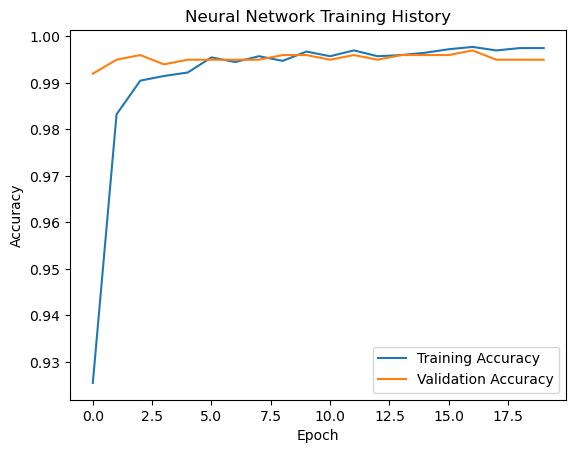

In [27]:

standard_y_pred_nn = (standard_model.predict(X_test) > 0.5).astype("int32")
print("Neural Network Accuracy:", accuracy_score(y_test, standard_y_pred_nn))
print(classification_report(y_test, standard_y_pred_nn))
lstm_y_pred_nn = (lstm_model.predict(X_test) > 0.5).astype("int32")
print("LSTM Accuracy:", accuracy_score(y_test, lstm_y_pred_nn))
print(classification_report(y_test, lstm_y_pred_nn))

    

# Plot training history
plt.plot(standard_history.history['accuracy'], label='Training Accuracy')
plt.plot(standard_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Neural Network Training History')
plt.show()


Based on the above code, write your own code to develop other ML or Neural network algorithms from list below.

Machine Learning Algorithms
**bold text**
Decision Tree Classifier:  https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

K-Nearest Neighbors (KNN):  https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Naive Bayes Classifier: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html


**Deep Learning Models**
Long Short-Term Memory (LSTM): https://keras.io/api/layers/recurrent_layers/lstm/

Convolutional Neural Networks (CNN): https://keras.io/api/layers/convolution_layers/convolution1d/

Transformers (Hugging Face Transformers)

**Important: Lab-Logbbok requirement**

Provide a bar graph comparing accuracy, precicion, recall, and f-score for various AI models



32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


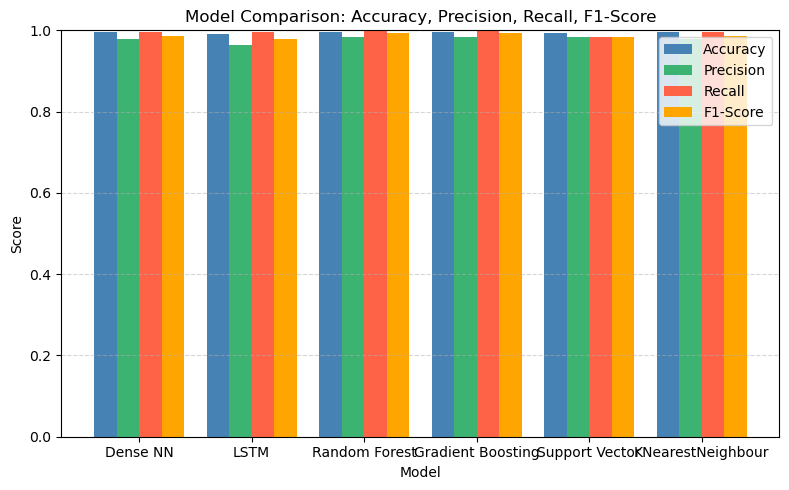

In [38]:
# Predictions
standard_y_pred_nn = (standard_model.predict(X_test) > 0.5).astype("int32")
lstm_y_pred_nn = (lstm_model.predict(X_test) > 0.5).astype("int32")

# Compute metrics for each model
models = ['Dense NN', 'LSTM', 'Random Forest', 'Gradient Boosting', 'Support Vector', 'KNearestNeighbour']
preds  = [standard_y_pred_nn, lstm_y_pred_nn, y_pred_rf, y_pred_gb, y_pred_svm, y_pred_neigh]

accuracy  = [accuracy_score(y_test, p)               for p in preds]
precision = [precision_score(y_test, p, zero_division=0) for p in preds]
recall    = [recall_score(y_test, p, zero_division=0)    for p in preds]
f1        = [f1_score(y_test, p, zero_division=0)        for p in preds]

# Bar chart
x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - 1.5*width, accuracy,  width, label='Accuracy',  color='steelblue')
ax.bar(x - 0.5*width, precision, width, label='Precision', color='mediumseagreen')
ax.bar(x + 0.5*width, recall,    width, label='Recall',    color='tomato')
ax.bar(x + 1.5*width, f1,        width, label='F1-Score',  color='orange')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy, Precision, Recall, F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()